<p style="text-align: center;"><span style="color: #ff0000;"><strong><span style="font-size: x-large;">
    MODELADO Y VISUALIZACIÓN GRÁFICA</span></strong></span></p>

<p style="text-align: center;"><span style="color: #0000ff;"><strong><span style="font-size: x-large;">PRÁCTICA 3</span></strong></span></p>
<p style="text-align: center;"><span style="color: #0000ff;"><strong><span style="font-size: x-large;">TRANSFORMACIONES GEOMÉTRICAS</span></strong></span></p>


En este tema veremos cómo transformar mallados poligonales 3D para obtener modelos nuevos. Las transformaciones geométricas son operaciones que nos permitirán, entre otras cosas:

* Crear múltiples copias de objetos en la escena.
* Cambiar la forma de los objetos.
* Posicionar objetos en una escena.

Organizamos la práctica según el siguiente índice:<a name="inicio"></a>


<p style="text-align: left;"> </p>
<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#rutant">0. Rutinas de prácticas anteriores.</a></strong> </span></p>

<p style="text-align: left;"> </p>
<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#tra">1. Traslaciones.</a></strong> </span></p>

<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#esc">2. Escalados.</a></strong> </span></p>

<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#rot">3. Rotaciones sobre ejes SRU.</a></strong> </span></p>


<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#sim">4. Simetrías sobre plano que pasa por el origen.</a></strong> </span></p>

<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#ses">5. Sesgos.</a></strong> </span></p>

<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#ejer">6. Ejercicios.</a></strong> </span></p>

<p><span style="color: #0000ff; font-size: large;"><strong>
<a href="#pro">7. Prontuario de rutinas de la práctica.</a></strong> </span></p>



<a name="rutant"></a>
## <span style="color:blue">0. Rutinas de prácticas anteriores.</span>

A continuación, con vistas a facilitar y agilizar su uso, se incluye una celda ejecutable con un compendio de las rutinas definidas en las sesiones previas.

In [1]:
def vector_puntos(P,Q):
    
    # Input: puntos P y Q
    # Output: vector PQ
    
    return (P.augment(Q))*matrix([[-1],[1]])

def producto_escalar(U,V):
    
    # Input: vectores U y V
    # Output: escalar U*V    
    
    return (transpose(U)*V)[0,0]

def modulo(U):
    
    # Input: vector U 
    # Output: escalar ||U||    
    
    return sqrt(producto_escalar(U,U))

def vector_unitario(U):
    
    # Input: vector U 
    # Output: vector unitario en la misma dirección y sentido que U    
    
    return U/modulo(U)

def coseno_del_angulo_que_forman(U,V):
    
    # Input: vectores U y V 
    # Output: escalar que representa el coseno del ángulo que forman U y V        
    
    return producto_escalar(U,V)/(modulo(U)*modulo(V))

def producto_vectorial(U,V):
    
    # Input: vectores U y V 
    # Output: vector producto vectorial UxV   
    
    W0 = U[1,0]*V[2,0] - U[2,0]*V[1,0]
    W1 = -U[0,0]*V[2,0] + U[2,0]*V[0,0]
    W2 = U[0,0]*V[1,0] - U[1,0]*V[0,0]
    return matrix([[W0],[W1],[W2],[0]])

In [2]:
def dibujar_poligono(vertices,**kwds):
    
    # Input: matriz con los vértices del polígono por columnas
    # Output: gráfica del polígono
    
    return polygon(tuple(vertices[0:3].transpose()),**kwds)

def dibujar_poligono_delimitado(vertices,**kwds):
    
    # Input: matriz con los vértices del polígono por columnas
    # Output: gráfica del polígono con el borde negro degrosor 50
    
    V = list(vertices[0:3].transpose())
    dib = polygon(V,**kwds)
    V.extend(vertices[0:3,0].transpose())
    dib += line3d(V, color ='black', thickness=50)
    return dib

In [3]:
#Meter las funciones de la práctica 1

def dibujar_punto(P,**kwds):
    
    #Input: punto P
    #Output: gráfica del punto
    
    return points(P[0:3].column(0),**kwds)

def dibujar_poligono(vertices,**kwds):
    
    # Input: matriz con los vértices del polígono por columnas
    # Output: gráfica del polígono
    
    return polygon(tuple(vertices[0:3].transpose()),**kwds)

def dibujar_poligono_delimitado(vertices,**kwds):
    
    # Input: matriz con los vértices del polígono por columnas
    # Output: gráfica del polígono con el borde negro degrosor 50
    
    V = list(vertices[0:3].transpose())
    dib = polygon(V,**kwds)
    V.extend(vertices[0:3,0].transpose())
    dib += line3d(V, color ='black', thickness=50)
    return dib

def dibujar_mallado_poligonal_delimitado(vertices,caras,**kwds):
    
    # Input: matriz con los vértices del polígono por columnas y matriz de caras.
    # Output: gráfica del mallado.
    
    mallado = 0
    for cara in caras:        
        indices = [n for n in cara if n>-1]
        vertices_de_la_cara = vertices[:,indices]
        mallado = mallado + dibujar_poligono_delimitado(vertices_de_la_cara,**kwds)
        
    return mallado

def dibujar_curva_Bezier(PC, **kwds):
    
    #Input: Puntos de control de la curva y color
    #Output: Dibujo de la curva
    
    t = var('t')
    B = matrix([[-1,3,-3,1],[3,-6,3,0],[-3,3,0,0],[1,0,0,0]])
    T = matrix([[t^3],[t^2],[t],[1]])
    C = matrix(PC[:,0:4]*B*T)
       
    return parametric_plot3d((C[0,0], C[1,0], C[2,0]), (0, 1), **kwds)

Volver al [índice](#inicio)

<a name="tra"></a>
## <span style="color:blue">1. Traslaciones.</span>


La traslación es una transformación matricial que permite desplazar objetos preservando líneas paralelas, ángulos y distancias.
Se define especificando el vector de desplazamiento $D = \left(\begin{array}{c}x_D\\y_D\\z_D\\0\end{array}\right)$, y su matriz de la transformación viene dada por: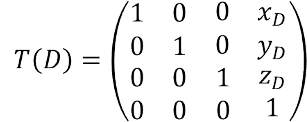

In [4]:
def traslacion(D): 
    
    #INPUT: vector D en coordenadas homogéneas
    #OUTPUT: matriz de traslación
         
    return matrix([[1,0,0,D[0,0]],[0,1,0,D[1,0]],[0,0,1,D[2,0]],[0,0,0,1]]) 


### <span style="color:blue">Ejemplo</span> 

A partir de las figuras elementales dadas a continuación, se pide modelar la figura:

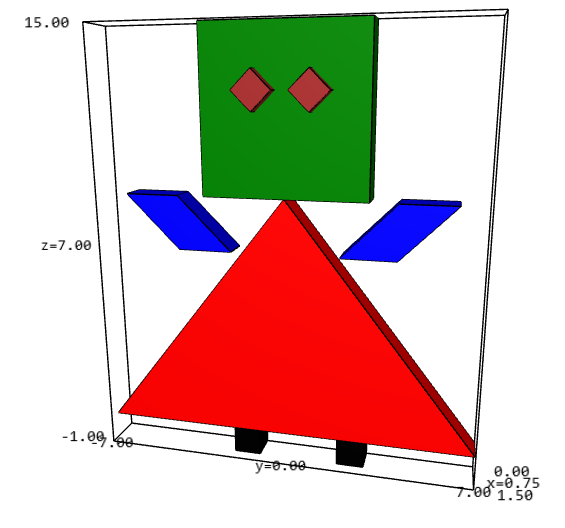




La primera figura elemental está formada por las matrices de vértices *cubovert* y la matriz de caras *cubocar*, y la segunda, a partir de la matriz de vértices *trivert* y la matriz de caras *tricar*.


In [5]:
cubovert = matrix([[1,0,0,1],[1,1,0,1],[1,1,1,1],[1,0,1,1],[0,0,0,1],[0,1,0,1],[0,1,1,1],[0,0,1,1]]).transpose()
trivert = matrix([[1,-1,0,1],[1,1,0,1],[1,0,1,1],[0,-1,0,1],[0,1,0,1],[0,0,1,1]]).transpose()

cubocar= matrix([[0,1,2,3],[1,0,4,5],[5,4,7,6],[2,1,5,6],[3,2,6,7],[0,3,7,4]])
tricar  =matrix([[0,1,2,-1],[1,0,3,4],[2,1,4,5],[0,2,5,3],[5,4,3,-1]])

show(cubovert)
show(cubocar)
show(trivert)
show(tricar)

[1 1 1 1 0 0 0 0]
[0 1 1 0 0 1 1 0]
[0 0 1 1 0 0 1 1]
[1 1 1 1 1 1 1 1]

[0 1 2 3]
[1 0 4 5]
[5 4 7 6]
[2 1 5 6]
[3 2 6 7]
[0 3 7 4]

[ 1  1  1  0  0  0]
[-1  1  0 -1  1  0]
[ 0  0  1  0  0  1]
[ 1  1  1  1  1  1]

[ 0  1  2 -1]
[ 1  0  3  4]
[ 2  1  4  5]
[ 0  2  5  3]
[ 5  4  3 -1]

Dibujamos las figuras elementales por separado:

In [6]:
dibujar_mallado_poligonal_delimitado(cubovert,cubocar,color='black') + \
dibujar_mallado_poligonal_delimitado(trivert,tricar,color='red')

Graphics3d Object

Observamos que ambas figuras se superponen, y procedemos a realizar una traslación del cubo para que conforme las piernas del muñeco a modelar:

In [7]:
D = matrix([[0],[0],[-1],[0]]) # vector de traslación D=(0,0,-1,0)
pierna1 = traslacion(D)*cubovert
dibujar_mallado_poligonal_delimitado(pierna1,cubocar,color='black') + \
dibujar_mallado_poligonal_delimitado(trivert,tricar,color='red')

Graphics3d Object

<a name="esc"></a>
## <span style="color:blue">2. Escalados.</span>


El escalado es una transformación matricial que permite cambiar el tamaño o la proporción de un objeto. Preserva líneas paralelas y no tiene porqué preservar ángulos ni distancias. Se define especificando la razón de escala, $𝒓$, en cada una de las direcciones: 

$r = \left(r_X,  r_Y, r_Z\right)$  tal que $𝑟_𝑋>0$, $𝑟_𝑌>0$, $𝑟_𝑍>0$, y su matriz de la transformación viene dada por:

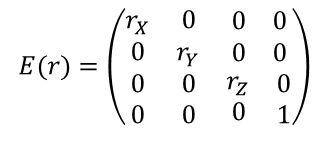

Cualquier escalado mantiene el origen de coordenadas invariante. <span style="color:red">Es muy importante tener en cuenta qué punto de nuestra figura vamos a mantener invariante </span>antes de escalar para que no se produzca un cambio indeseado en la posición del objeto.

In [8]:
def escalado(r):  
    
    #INPUT: r=[rx,ry,rz]
    #OUTPUT: matriz del escalado
         
    return matrix([[r[0],0,0,0],[0,r[1],0,0],[0,0,r[2],0],[0,0,0,1]]) 

### <span style="color:blue">Ejemplo</span> 

Volviendo al ejemplo, necesitamos que el cuerpo del muñeco sea un triángulo cuya base tenga longitud 14 y altura 9. Además queremos dejarlo fijo en el origen de coordenadas que se encuentra en la mitad de la base del triángulo. Realizaremos por tanto  un escalado de razon [1,7,9]:
    

In [9]:
r = [1,7,9]
cuerpo = escalado(r)*trivert
dibujar_mallado_poligonal_delimitado(pierna1,cubocar,color='black') + dibujar_mallado_poligonal_delimitado(cuerpo,tricar,color='red')

Graphics3d Object

Volver al [índice](#inicio)

Continuamos aplicando las trasformaciones necesarias de escalado y traslación para generar la cara y las piernas del muñeco:

In [10]:
D = matrix([[0],[2],[-1],[0]])
pierna1 = traslacion(D)*cubovert
D = matrix([[0],[-2],[-1],[0]])
pierna2 = traslacion(D)*cubovert
r = [1,6,6] # escalado de razón (1,6,6)
D = matrix([[0],[-3],[9],[0]])
cara = traslacion(D)*escalado(r)*cubovert
dib_pierna1 = dibujar_mallado_poligonal_delimitado(pierna1,cubocar,color='black') 
dib_pierna2 = dibujar_mallado_poligonal_delimitado(pierna2,cubocar,color='black')
dib_cuerpo = dibujar_mallado_poligonal_delimitado(cuerpo,tricar,color='red')
dib_cara = dibujar_mallado_poligonal_delimitado(cara,cubocar,color='green')
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara

Graphics3d Object

Observa que para modelar la cara, es necesario realizar escalado y traslación. **Comprueba que si invertimos el orden en que estas transformaciones se efectúan, el resultado cambia**.

<a name="rot"></a>
## <span style="color:blue">3. Rotaciones sobre ejes SRU.</span>


La rotación es una transformación matricial que permite girar objetos preservando líneas paralelas, ángulos y distancias. Se define especificando el eje respecto al cuál queremos rotar así como el ángulo de rotación $\varphi$. La rotación deja invariante todos los puntos contenidos en el eje de rotación. A continuación, se muestran las matrices de rotación cuando ésta se efectúa sobre uno de los ejes del SRU: 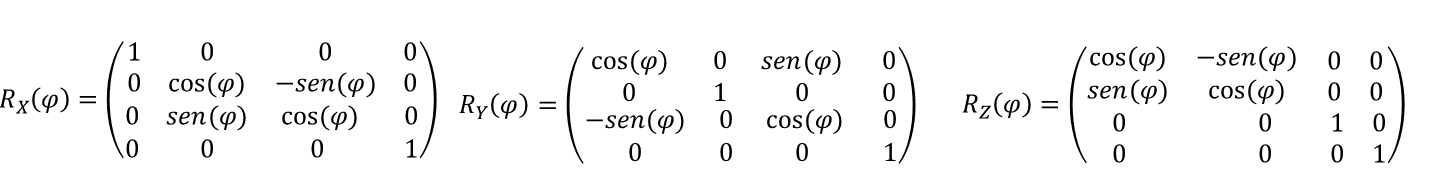

In [11]:
def rotacion(eje,angulo):
    
    #INPUT: eje='x', 'y' o 'z'
    #       angulo en radianes
    #OUTPUT: matriz de rotación
    
    if eje == 'x':
        M = matrix([[1,0,0,0],[0,cos(angulo),-sin(angulo),0],[0,sin(angulo),cos(angulo),0],[0,0,0,1]])
    elif eje == 'y':
        M = matrix([[cos(angulo),0,sin(angulo),0],[0,1,0,0],[-sin(angulo),0,cos(angulo),0],[0,0,0,1]])    
    else:
        M = matrix([[cos(angulo),-sin(angulo),0,0],[sin(angulo),cos(angulo),0,0],[0,0,1,0],[0,0,0,1]])   
        
    return M

def rotacion_coseno(eje,coseno,seno):
    
    #INPUT: eje='x', 'y' o 'z'
    #       coseno y seno del ángulo de rotación
    #OUTPUT: matriz de rotación
    
    if eje == 'x':
        M = matrix([[1,0,0,0],[0,coseno,-seno,0],[0,seno,coseno,0],[0,0,0,1]])
    elif eje == 'y':
        M = matrix([[coseno,0,seno,0],[0,1,0,0],[-seno,0,coseno,0],[0,0,0,1]])    
    else:
        M = matrix([[coseno,-seno,0,0],[seno,coseno,0,0],[0,0,1,0],[0,0,0,1]])   
        
    return M

### <span style="color:blue">Ejemplo</span> 

Para modelar los ojos del muñeco, necesitamos rotar el modelo base, las dimensiones son las adecuadas y el eje de rotación al tratarse de una rotación plana debe pasar por el centro del cuadrado. En este caso se trata del el eje $x$. Seguidamente lo trasladaremos a la posición adecuada.

In [12]:
D = matrix([[1/2],[-1],[12],[0]]) # vector de traslación D = (1/2,-1,12,0)
ojo1 =  traslacion(D) *rotacion('x',pi/4)*cubovert
dib_ojo1 = dibujar_mallado_poligonal_delimitado(ojo1,cubocar,color='brown')
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1

Graphics3d Object

Observa que para modelar el ojo, es necesario realizar rotación y traslación. **Comprueba que si invertimos el orden en que estas transformaciones se efectúan, el resultado cambia**.

Volver al [índice](#inicio)

<a name="sim"></a>
## <span style="color:blue">4. Simetrías sobre plano que pasa por el origen.</span>


La simetría es una transformación matricial que permite reflejar objetos (como si se tratara de un espejo). Preserva líneas paralelas, ángulos y distancias y se define especificando un vector <span style="color:red">unitario </span>$𝑁=\left(x_𝑁,𝑦_𝑁,𝑧_𝑁,0\right)$  normal a un plano de simetría <span style="color:red">que pase por el origen de coordenadas</span>. La simetría deja invariante todos los puntos contenidos en dicho plano de simetría.

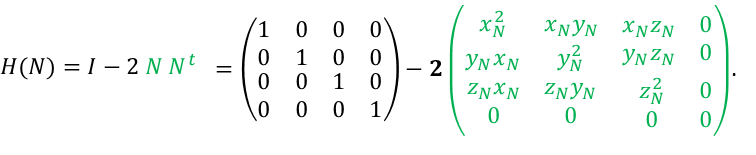

In [13]:
def simetria(N):
    
    #INPUT: N vector normal al plano de simetría en coordenadas homogéneas
    #OUTPUT: matriz de simetría
    
    N = N/norm(N)
    I = matrix([[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]])
    
    return I-2*N*N.transpose()

### <span style="color:blue">Ejemplo</span> 

Continuamos modelando el ejemplo del muñeco. Para ello, vamos a hacer una simetría que nos permita modelar el segundo ojo del mismo a partir del que ya tenemos modelado. En este caso nuestro plano de simetría será el plano $XZ$ que, por supuesto, pasa por el origen de coordenadas, así no tendremos nada que trasladar.

In [14]:
N = matrix([[0],[1],[0],[0]]) # vector normal N=(0,1,0,0)
ojo2 =  simetria(N) * ojo1
dib_ojo2 = dibujar_mallado_poligonal_delimitado(ojo2,cubocar,color='brown')
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2

Graphics3d Object

Observa que el plano de simetría tiene vector normal (0,1,0,0). Se trata por tanto del plano y=0

Volver al [índice](#inicio)

<a name="ses"></a>
## <span style="color:blue">5. Sesgos.</span>


El sesgo es una transformación matricial que permite desplazar puntos en función de los valores de sus coordenadas. 
Preserva líneas paralelas, y no preserva ángulos ni distancias.
El sesgo se define especificando: La dirección de inclinación ($𝑒𝑗𝑒_1$), y los ángulos de inclinación respecto a otras direcciones ($𝑒𝑗𝑒_2$, $𝑒𝑗𝑒_3$), medidos desde éstas hasta $𝑒𝑗𝑒_1$. El sesgo deja invariante las coordenadas de $𝑒𝑗𝑒_2$ y $𝑒𝑗𝑒_3$.

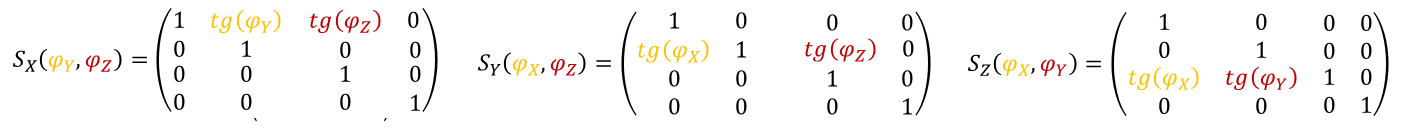

In [15]:

def sesgo(direccion,ang1,ang2):
    
    #INPUT: direccion ='x', 'y' o 'z'
    #       angulos ang1 y ang2  en radianes
    #OUTPUT: matriz de sesgo

    if direccion == 'x':
        M = matrix([[1, tan(ang1), tan(ang2), 0],[0, 1, 0, 0],[0, 0, 1, 0],[0, 0, 0, 1]])
    
    elif direccion == 'y':
        M = matrix([[1 ,0 ,0 ,0],[ tan(ang1), 1, tan(ang2), 0],[0, 0, 1, 0],[0, 0, 0, 1]])
    
    else:
        M = matrix([[1, 0, 0, 0],[0, 1, 0, 0],[tan(ang1), tan(ang2), 1, 0],[0, 0, 0, 1]])
        
    return M

def sesgo_tangente(direccion,tan1,tan2):
    
    #INPUT: direccion ='x', 'y' o 'z'
    #       tangentes de los angulos ang1 y ang2 
    #OUTPUT: matriz de sesgo

    if direccion == 'x':
        M = matrix([[1, tan1, tan2, 0],[0, 1, 0, 0],[0, 0, 1, 0],[0, 0, 0, 1]])
    
    elif direccion == 'y':
        M = matrix([[1 ,0 ,0 ,0],[ tan1, 1,tan2, 0],[0, 0, 1, 0],[0, 0, 0, 1]])
    
    else:
        M = matrix([[1, 0, 0, 0],[0, 1, 0, 0],[tan1, tan2, 1, 0],[0, 0, 0, 1]])
        
    return M


### <span style="color:blue">Ejemplo</span> 

Para modelar los brazos del muñeco vamos a utilizar la transformación de sesgo sobre la primera figura base. Observamos además que posteriormente es necesario escalarla y trasladarla adecuadamente:

In [16]:

r=[1,2,2]
D = matrix([[0],[2],[7],[0]])
brazo1 = traslacion(D) * escalado(r) * sesgo('y',0,pi/4) * cubovert
brazo2 = simetria(N) * brazo1
dib_brazo1 = dibujar_mallado_poligonal_delimitado(brazo1, cubocar,color = 'blue')
dib_brazo2 = dibujar_mallado_poligonal_delimitado(brazo2, cubocar,color = 'blue')
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2 + dib_brazo1 + dib_brazo2


Graphics3d Object

Observa que para modelar los brazos, hemos efectuado varias transformaciones. **Comprueba qué ocurre si modificamos el orden en que estas transformaciones se efectúan.**

Volver al [índice](#inicio)

<a name="ses"></a>
## <span style="color:blue">6. Trasladando los puntos de control de una curva de Bézier.</span>

Ahora vamos a añadir al dibujo una boca y las orejas usando curvas de Bézier. Para hacerlo, considera la curva de Bézier difinida a partir de la siguiente matriz de puntos de control.
$$PC = \left(\begin{array}{cccc}1 & 1 & 1 & 1\\
0 & 1 & 3 & 4\\
1.5 & 0 & 0 & 1.5\\
1 & 1 & 1 & 1
\end{array}\right)$$

In [17]:
PC = matrix([[1,1,1,1],[0,1,3,4],[1.5,0,0,1.5],[1,1,1,1]])
curva =dibujar_curva_Bezier(PC, color = 'black', thickness = 200)
curva

Graphics3d Object

In [18]:
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2 + dib_brazo1 + dib_brazo2 + curva

Graphics3d Object

Ahora tendremos que mover la curva a la altura de la boca. Para ello hacemos una traslación de los puntos de control.We need to move the curve to the location of the mouth. To do this, we move the control points.

In [19]:
PC = matrix([[1,1,1,1],[0,1,3,4],[1.5,0,0,1.5],[1,1,1,1]])
D = matrix([[0],[-2],[10],[0]])
PC_trans = traslacion(D)*PC
boca=dibujar_curva_Bezier(PC_trans, color = 'black', thickness = 200)
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2 + dib_brazo1 + dib_brazo2 + boca

Graphics3d Object

Para crear las orejas desde la curva original tendremos que aplicar varias transformaciones a los puntos de control. Debemos de aplicarlas en el orden adecuado.

In [20]:
PC = matrix([[1,1,1,1],[0,1,3,4],[1.5,0,0,1.5],[1,1,1,1]])
r=(1,1/2,1)
PC_sca=escalado(r)*PC   #scaling over the second coordinate
PC_rot=rotacion('x',-pi/2)*PC_sca
D= matrix([[0],[-4.5],[13],[0]])
PC_tras=traslacion(D)*PC_rot
oreja=dibujar_curva_Bezier(PC_tras, color = 'black', thickness = 200)
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2 + dib_brazo1 + dib_brazo2 + boca + oreja

Graphics3d Object

Finalmente, para la segunda oreja, aplicamos una simetría a la primera respecto del plano y=0.

In [21]:
N = matrix([[0],[1],[0],[0]])
PC_orej_2 = simetria(N)*PC_tras
oreja_2=dibujar_curva_Bezier(PC_orej_2, color = 'black', thickness = 200)
dib_pierna1 + dib_pierna2 + dib_cuerpo + dib_cara + dib_ojo1 + dib_ojo2 + dib_brazo1 + dib_brazo2 + boca + oreja + oreja_2

Graphics3d Object

<a name="ejer"></a>
## <span style="color:blue"> 7. Ejercicios para practicar</span>

### <span style="color:blue">Ejercicio 1.</span>

#### <span style="color:blue">a)</span>
Se pretende modelar la copa del árbol de navidad adjunto como la superficie cerrada delimitada por 8 ramas, provenientes de las
rotaciones sucesivas sobre el tronco de la rama elemental que conforman las 4 caras triangulares determinadas por $(Q_1,Q_2,O)$,$(Q_2,Q_3,O)$,$(Q_1,Q_2,C)$ y $(Q_2,Q_3,C)$ con $O=\left(\begin{array}{c}0\\0\\0\\1\end{array}\right)$, $C=\left(\begin{array}{c}0\\0\\2\\1\end{array}\right)$, $Q_1=\left(\begin{array}{c}1\\1-\sqrt{2}\\0\\1\end{array}\right)$, $Q_2=\left(\begin{array}{c}\frac{6}{5}\\0\\-\frac{1}{4}\\1\end{array}\right)$ y  $Q_3=\left(\begin{array}{c}1\\\sqrt{2}-1\\0\\1\end{array}\right)$
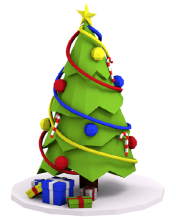

A continuación, representamos graficamente las caras de las que hablamos en el enunciado y que serán nuestro punto de partida.

In [24]:
#matriz con los vértices que conforman la rama verde (C,Q1,Q2,Q3)
vertices = matrix([[0,0,2,1],[1,1-sqrt(2),0,1],[6/5,0,-1/4,1],[1,sqrt(2)-1,0,1]]) 
vertices = vertices.transpose()
show('C,Q1,Q2,Q3=',vertices)

#matriz con los vértices que conforman la tapa amarilla (C,Q1,Q2,Q3)
vertices_tapa = matrix([[0,1,6/5,1],[0,1-sqrt(2),0,sqrt(2)-1],[0,0,-1/4,0],[1,1,1,1]]) #matriz con los vértices  (O,Q1,Q2,Q3)
show('O,Q1,Q2,Q3=',vertices_tapa)

caras = matrix([[0,2,1],[0,3,2]])

carama = dibujar_mallado_poligonal_delimitado(vertices,caras,color = 'green')
caraver = dibujar_mallado_poligonal_delimitado(vertices_tapa,caras,color = 'yellow')

carama + caraver

'C,Q1,Q2,Q3=' [           0            1          6/5            1]
[           0 -sqrt(2) + 1            0  sqrt(2) - 1]
[           2            0         -1/4            0]
[           1            1            1            1]

'O,Q1,Q2,Q3=' [           0            1          6/5            1]
[           0 -sqrt(2) + 1            0  sqrt(2) - 1]
[           0            0         -1/4            0]
[           1            1            1            1]

Graphics3d Object

Para obtener la parte más alta de la copa del árbol sólo tenemos que realizar 8 transformaciones de la rama base, rotándola sucesivamente con ángulos de $\pi/4$ alrededor del eje z.

In [28]:
P = copy(vertices)
P_tapa = copy(vertices_tapa)
C = copy(caras)



Graphics3d Object

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>


P = copy(vertices)
P_tapa = copy(vertices_tapa)
C = copy(caras)

for i in [1..7]:
    rama = rotacion('z',i*pi/4)*P
    rama_tapa = rotacion('z',i*pi/4)*P_tapa
    vertices = vertices.augment(rama[:,2:4])
    vertices_tapa = vertices_tapa.augment(rama_tapa[:,2:4])
    caras = caras.stack(matrix([[0,2+2*i,1+2*i],[0,3+2*i,2+2*i]]))

mallado = dibujar_mallado_poligonal_delimitado(vertices,matrix(caras),color = 'green')
mallado_tapa = dibujar_mallado_poligonal_delimitado(vertices_tapa,matrix(caras),color = 'yellow')

show(mallado + mallado_tapa)

</details>

Para obtener la segunda parte de la copa del árbol bastará con escalar la parte más alta (para aumentarle el tamaño con razón $(1.3,1.3,1.3)$ por ejemplo) y trasladada hacia la parte negativa del eje z.

Graphics3d Object

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

D1 = matrix([[0],[0],[-1],[0]])
r1 = (1.3,1.3,1.3)

vertices2 = traslacion(D1)*escalado(r1)*vertices
vertices_tapa2 = traslacion(D1)*escalado(r1)*vertices_tapa

mallado2 = dibujar_mallado_poligonal_delimitado(vertices2,matrix(caras),color = 'green')
mallado_tapa2 = dibujar_mallado_poligonal_delimitado(vertices_tapa2,matrix(caras),color = 'yellow')

show(mallado + mallado_tapa + mallado2 + mallado_tapa2)
</details>

De nuevo repetimos el proceso para las partes 3 y 4 del árbol.

Graphics3d Object

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

D2 = matrix([[0],[0],[-1],[0]])
r2 = (1.3,1.3,1.3)

vertices3 = traslacion(D2)*escalado(r2)*vertices2
vertices_tapa3 = traslacion(D2)*escalado(r2)*vertices_tapa2

mallado3 = dibujar_mallado_poligonal_delimitado(vertices3,matrix(caras),color = 'green')
mallado_tapa3 = dibujar_mallado_poligonal_delimitado(vertices_tapa3,matrix(caras),color = 'yellow')

show(mallado + mallado_tapa + mallado2 + mallado_tapa2 + mallado3 + mallado_tapa3)
</details>

Y finalmente obtenemos la copa completa del árbol que estabamos buscando.

Graphics3d Object

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

D3 = matrix([[0],[0],[-1],[0]])
r3 = (1.3,1.3,1.3)

vertices4 = traslacion(D3)*escalado(r3)*vertices3
vertices_tapa4 = traslacion(D3)*escalado(r3)*vertices_tapa3

mallado4 = dibujar_mallado_poligonal_delimitado(vertices4,matrix(caras),color = 'green')
mallado_tapa4 = dibujar_mallado_poligonal_delimitado(vertices_tapa4,matrix(caras),color = 'yellow')

show(mallado + mallado_tapa + mallado2 + mallado_tapa2 + mallado3 + mallado_tapa3 + mallado4 + mallado_tapa4)
</details>

#### <span style="color:blue">b)</span>

En la figura siguiente, sabemos que la bola azul de este árbol proviene de la transformación geométrica de la bola roja. Si conocemos que las coordenadas del punto donde está situada la bola azul son $P_{azul} = \left(\begin{array}{c}1.831\\-0.12759\\-2.928\\1\end{array}\right)$, ¿podrías deducir las coordenadas del punto donde está situada la bola roja $P_{roja}$?

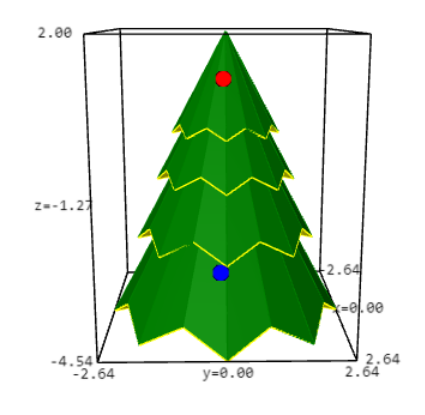

Para averiguarlo tendremos que aplicar las transformaciones inversas a las hechas anteriormente en la construcción de la parte 4 de la copa del árbol al punto A. En el caso de las traslaciones serán también traslaciones con vector de desplazamiento opuesto y en el caso de los escalados serán también escalados con los razones inversas en cada componente.

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

Pazul = matrix(RR,[[1.831,-0.12759,-2.928,1]]).transpose() #bola azul
ir1 = (1/1.3,1/1.3,1/1.3)
ir2 = (1/1.3,1/1.3,1/1.3)
ir3 = (1/1.3,1/1.3,1/1.3)
Proja = traslacion(-D3)*escalado(ir3)*traslacion(-D2)*escalado(ir2)*traslacion(-D1)*escalado(ir1)*Pazul
show('Bola roja=',Proja)

DR = dibujar_punto(Proja,color='red',size=80)
DA = dibujar_punto(Pazul,color='blue',size=80)
show(mallado + mallado_tapa + mallado2 + mallado_tapa2 + mallado3 + mallado_tapa3 + mallado4 + mallado_tapa4 + DA + DR)

</details>

Volver al [índice](#inicio)

### <span style="color:blue">Ejercicio 2.</span>
#### <span style="color:blue"> a) </span>
Conocidas las coordenadas de los vértices del rombo definido por el polígono $(O,P_1,P_2,P_3)$ dadas por $O=\left(\begin{array}{c}0\\0\\0\\1\end{array}\right)$, $P_1=\left(\begin{array}{c}1\\1-\sqrt{2}\\0\\1\end{array}\right)$, $P_2=\left(\begin{array}{c}2\\0\\0\\1\end{array}\right)$ y $P_3=\left(\begin{array}{c}1\\\sqrt{2}-1\\0\\1\end{array}\right)$, hallar las coordenadas de los vértices de la estrella octogonal adjunta

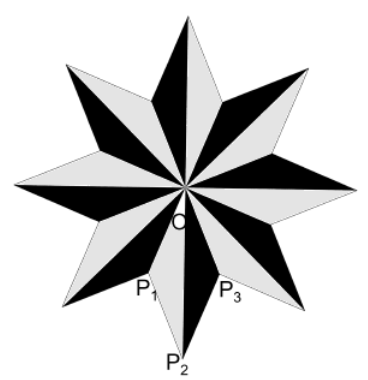

Comenzamos definiendo los vértices O, P1, P2 y P3 así como las dos caras (negra y blanca) que componen cada uno de los rombos de la estrella: (O, P2, P1) y (O, P3, P2)

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

vertices = matrix([[0,0,0,1],[1,1-sqrt(2),0,1],[2,0,0,1],[1,sqrt(2)-1,0,1]])
vertices = vertices.transpose()
show('Vértices O, P1, P2, P3 = ',vertices)
caras = matrix([[0,2,1],[0,3,2]])
carab = dibujar_poligono_delimitado(vertices[:,list(caras[0])],color = 'white')
caran = dibujar_poligono_delimitado(vertices[:,list(caras[1])],color = 'black')
carab + caran
</details>

Generamos los vértices restantes de la estrella aplicando sucesivas rotaciones sobre el eje z de ángulo $i\pi/4$ con i=1,...,7 a los vértices originales.

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>
P = copy(vertices)
C = copy(caras)
for i in [1..7]:
    vertices_rotados = rotacion('z',i*pi/4)*P
    vertices = vertices.augment(vertices_rotados)
    caras = caras.stack(matrix([[0,2+4*i,1+4*i],[0,3+4*i,2+4*i]])) 
</details>

Para dibujarlas, recorremos toda la matriz de caras creada anteriormente y vamos alternando color blanco y negro.

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>
for i in [1..7]:
    carab = carab + dibujar_poligono_delimitado(vertices[:,list(caras[2*i])],color = 'white')
    caran = caran + dibujar_poligono_delimitado(vertices[:,list(caras[2*i+1])],color = 'black')
carab + caran
</details>

#### <span style="color:blue"> b) </span>

Si sabemos que las coordenadas del punto rojo sobre la estrella son $P_{rojo}=\left(\begin{array}{c}1.2\\0.25\\0.01\\1\end{array}\right)$ y el punto azul $P_{azul}$ es el resultado de una transformación geométrica (o una secuencia de ellas) de éste, ¿cuáles serían las coordenadas exactas del punto azul?

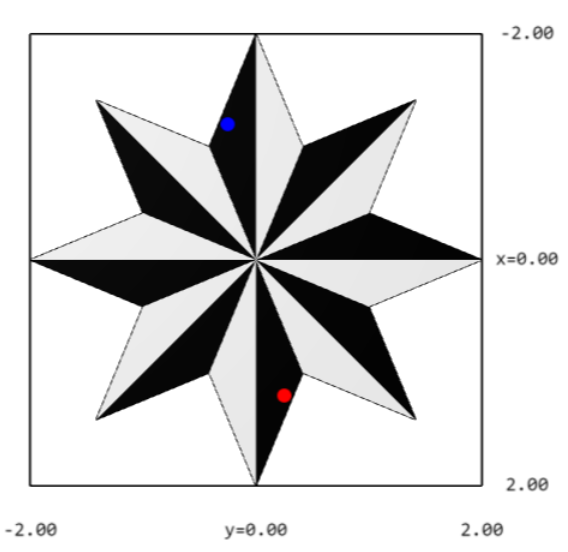

Podemos ver que se trata de una rotación sobre el eje z de ángulo $\pi$

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

Projo = matrix([[1.2,0.25,0.01,1]]).transpose()
Pazul = rotacion('z',pi)*Projo

dib_Projo = dibujar_punto(Projo, color = 'red', size=30)
dib_Pazul = dibujar_punto(Pazul, color = 'blue', size=30)

carab + caran + dib_Projo + dib_Pazul

#Por tanto el punto azul tendrá coordenadas...
show('Punto azul=',Pazul)
</details>

#### <span style="color:blue"> c) </span>

También sabemos que el punto verde sobre la estrella es el resultado de aplicar una rotación alrededor del eje z del punto. Sabiendo que el punto verde tiene coordenadas $P_{verde}=\left(\begin{array}{c}−0.383493649053890\\−1.16423048454133\\0.01\\1\end{array}\right)$, calcula el ángulo de rotación que se ha usado para calcular dicho punto verde. 

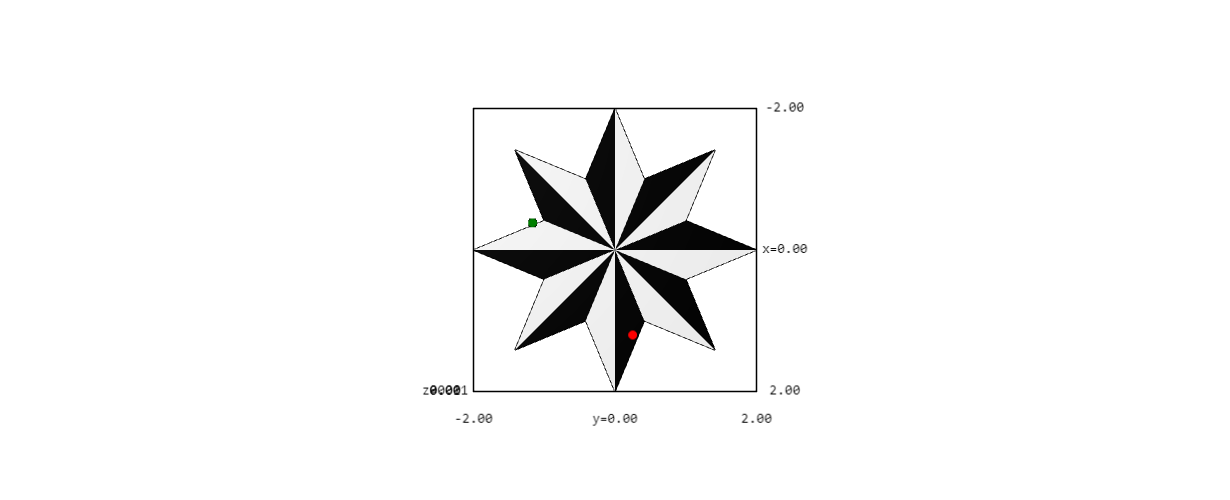

Dado que el ángulo de giro es el eje z, los dos puntos tienen la misma coordenada z y pertenecen al plano $z=0.01$, además el punto O_proy (origen proyectado sobre dicho plano) con coordenadas $O_proy=\left(\begin{array}{c}0\\0\\0.01\\1\end{array}\right)$ se mantiene constante en este giro. Así podremos construir dos vectores OproyProjo y OproyPverde que son el segundo imagén del primero y se encuentran en un plano perpendicular al eje. Usando el producto escalar podemos obtener el angulo que forman que coincidirá con el ángulo de giro. Para saber el sentido del giro por tratarse del eje z miramos la tercera coordenada del producto vectorial de los vectores.

<details><summary>
Solución (pincha aquí para verla). Para ejecutar el código pégalo en una nueva celda tipo Code.
</summary>

Projo = matrix([[1.2,0.25,0.01,1]]).transpose()
Pverde = matrix([[-0.383493649053890,-1.16423048454133,0.01,1]]).transpose()
O_proy=matrix([[0,0,0.01,1]]).transpose()
P_VO_proy=vector_puntos(Pverde,O_proy)
P_RO_proy=vector_puntos(Projo,O_proy)
cos=coseno_del_angulo_que_forman(P_RO_proy,P_VO_proy)
angulo_abs=arccos(cos)*180/pi
sign(producto_vectorial(P_RO_proy,P_VO_proy)[2][0])
show(angulo_abs.n()*sign(producto_vectorial(P_RO_proy,P_VO_proy)[2][0]))
</details>

Volver al [índice](#inicio)